# Obesity - Waste Analysis

Create an output folder and import all required libraries.

In [509]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pysal.lib as ps
import mapclassify
from matplotlib.colors import LinearSegmentedColormap
from pysal.lib import weights
from pysal.explore import esda
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Create outputs directory
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)


Read in the CSV and shapefile sources.

In [510]:
dsny     = pd.read_csv("data/dsny.csv")
pop      = pd.read_csv("data/pop.csv")
rest     = pd.read_csv("data/rest.csv")
obesity  = pd.read_csv("data/obesity.csv")
boro_gdf = gpd.read_file("data/nybb_25a/nybb.shp")
cd_gdf   = gpd.read_file("data/nycd_25a/nycd.shp")


/var/folders/kl/fcwqs6xs30b3g73_r8l0_q5m0000gn/T/ipykernel_45998/402070068.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  obesity  = pd.read_csv("data/obesity.csv")


In [511]:
dsny.head()

,MONTH,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,PAPERTONSCOLLECTED,MGPTONSCOLLECTED,RESORGANICSTONS,SCHOOLORGANICTONS,LEAVESORGANICTONS,XMASTREETONS,BOROUGH_ID
0,2024 / 01,Manhattan,05,1261.7,270.8,166.7,NaN,NaN,NaN,12.6,1.0
1,2023 / 07,Queens,07,6821.7,735.8,757.8,101.5,NaN,NaN,NaN,4.0
2,2023 / 12,Bronx,10,2603.9,353.3,348.8,NaN,NaN,8.6,NaN,2.0
3,2024 / 01,Bronx,05,3389.6,223.2,334.1,NaN,74.9,NaN,3.8,2.0
4,2024 / 03,Brooklyn,17,3985.8,281.7,387.4,51.8,NaN,NaN,NaN,3.0


In [512]:
pop.head()

,Borough,CD Number,CD Name,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population
0,Bronx,1,"Melrose, Mott Haven, Port Morris",138557,78441,77214,82159,91497
1,Bronx,2,"Hunts Point, Longwood",99493,34399,39443,46824,52246
2,Bronx,3,"Morrisania, Crotona Park East",150636,53635,57162,68574,79762
3,Bronx,4,"Highbridge, Concourse Village",144207,114312,119962,139563,146441
4,Bronx,5,"University Hts., Fordham, Mt. Hope",121807,107995,118435,128313,128200


In [513]:
rest.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location Point1
0,50071654,TASTEE PATTEE BAKERY AND GRILL,Brooklyn,987,FLATBUSH AVENUE,11226.0,7184841979,Caribbean,01/17/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.647175,-73.958119,314.0,40.0,79400.0,3117679.0,3.051260e+09,BK95,NaN
1,50082531,KENNEDY FRIED CHICKEN,Bronx,1220,OGDEN AVENUE,10452.0,6469059373,Chicken,03/01/2023,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.838249,-73.926329,204.0,16.0,19900.0,2003298.0,2.025160e+09,BX26,NaN
2,50067314,KABAB KING,Queens,7301,37TH RD,11372.0,7184575857,Pakistani,02/17/2023,Establishment re-closed by DOHMH.,...,Cycle Inspection / Reopening Inspection,40.747154,-73.892274,403.0,25.0,28900.0,4029791.0,4.012840e+09,QN28,NaN
3,50036313,NYC HANDCRAFTED,Manhattan,367,3 AVENUE,10016.0,2126893000,American,06/27/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.741061,-73.981505,106.0,2.0,6600.0,1019864.0,1.009070e+09,MN20,NaN
4,41037770,SUNNY'S,Brooklyn,253,CONOVER STREET,11231.0,7186242932,American,10/19/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.675733,-74.016973,306.0,38.0,5300.0,3008865.0,3.006100e+09,BK33,NaN


In [514]:
obesity.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2022,AL,Alabama,Clay,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,11.0,...,9.6,12.4,14198,11235,1027,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-85.8606604130173 33.2693085517833)
1,2022,AL,Alabama,Dale,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,35.6,...,34.8,36.4,49544,38039,1045,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-85.6109266826185 31.4316629601359)
2,2022,AL,Alabama,Jackson,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.1,...,4.6,5.6,52891,42087,1071,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-85.9995052603961 34.7796392771775)
3,2022,AL,Alabama,Lauderdale,BRFSS,Health Outcomes,Obesity among adults,%,Age-adjusted prevalence,36.5,...,29.6,43.9,95878,77472,1077,HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-87.6540983850983 34.9014438477101)
4,2022,AL,Alabama,Lawrence,BRFSS,Disability,Any disability among adults,%,Crude prevalence,40.1,...,35.5,44.7,33214,26022,1079,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-87.3108851040374 34.5216735395968)


### Process Obesity Data

Filter for NY State, the “Obesity” measure, map counties to boroughs, and keep age-adjusted prevalence.

In [515]:
# Standardize column names
dsny.columns = dsny.columns.str.lower()
pop.columns  = pop.columns.str.lower()

# Filter BRFSS obesity data
obesity = obesity[
    (obesity['StateAbbr'] == 'NY') &
    (obesity['Short_Question_Text'] == 'Obesity') &
    (obesity['Data_Value_Type'] == 'Age-adjusted prevalence')
]

# Select & rename
obesity = obesity[['LocationName','Data_Value']].rename(
    columns={'LocationName':'county','Data_Value':'obesity_rate'}
)

# Map to NYC boroughs
county_to_boro = {
    'Bronx':    'Bronx',
    'Kings':    'Brooklyn',
    'Queens':   'Queens',
    'Richmond': 'Staten Island',
    'New York': 'Manhattan'
}
obesity['borough'] = obesity['county'].map(county_to_boro)

# Clean up
obesity['obesity_rate'] = pd.to_numeric(obesity['obesity_rate'], errors='coerce')
obesity = obesity.dropna(subset=['borough']).reset_index(drop=True)


### Clean & Aggregate DSNY Waste Data

Fill missing streams with zero and compute mean tonnage per community district.

In [516]:
# Ensure 2-digit codes
dsny['communitydistrict'] = dsny['communitydistrict'].astype(str).str.zfill(2)

# Fill NaNs and total waste
for col in ['refusetonscollected','papertonscollected','mgptonscollected','resorganicstons']:
    dsny[col] = dsny[col].fillna(0)
dsny['total_waste'] = dsny[['refusetonscollected','papertonscollected','mgptonscollected']].sum(axis=1)

# Aggregate by CD
dsny_cd = dsny.groupby('communitydistrict').agg({
    'refusetonscollected':'mean',
    'papertonscollected':'mean',
    'mgptonscollected':'mean',
    'resorganicstons':'mean',
    'total_waste':'mean'
}).reset_index()


### Build Community District --> Borough Lookup

Derive borough names and 2-digit CD codes from the BoroCD field in the CD shapefile

In [517]:
# Map borough codes
borough_map = {1:'Manhattan',2:'Bronx',3:'Brooklyn',4:'Queens',5:'Staten Island'}

cd_gdf['borough'] = (cd_gdf['BoroCD'] // 100).map(borough_map)
cd_gdf['communitydistrict'] = (cd_gdf['BoroCD'] % 100).astype(str).str.zfill(2)

cd_to_boro = cd_gdf[['communitydistrict','borough']].drop_duplicates()


### Prepare Population Data

Extract 2-digit CD codes from the DCP population file.

In [518]:
# Assume pop has columns 'cd number' and '2010 population'
pop = pop[['cd number','2010 population']].rename(
    columns={'2010 population':'population'}
)
pop['communitydistrict'] = (pop['cd number'] % 100).astype(int).astype(str).str.zfill(2)
pop = pop[['communitydistrict','population']]


### Prepare Restaurant Density

Use the DOHMH “Community Board” field to count inspections per CD.

In [519]:
rest = rest.dropna(subset=['Community Board'])
rest['communitydistrict'] = (
    rest['Community Board'].astype(int).mod(100)
    .astype(str).str.zfill(2)
)
rest = rest.groupby('communitydistrict') \
           .size().reset_index(name='restaurant_count')


### Merge All Sources & Compute Per-Capita Rates

Join DSNY, borough lookup, population, restaurants, and obesity, then calculate per-person metrics.

In [520]:
merged = (
    dsny_cd
      .merge(cd_to_boro, on='communitydistrict', how='left')
      .merge(pop,        on='communitydistrict', how='left')
      .merge(rest,       on='communitydistrict', how='left')
      .merge(obesity,    on='borough',           how='left')
)

# Per-capita waste and restaurant density
for c in ['refusetonscollected','papertonscollected','mgptonscollected','resorganicstons','total_waste']:
    merged[f'{c}_pc'] = merged[c] / merged['population']

merged['rest_density'] = merged['restaurant_count'] / merged['population']

### Borough-Level Correlation

Compute and display the correlation matrix of mean per-capita packaging, organics, restaurant density, and obesity.

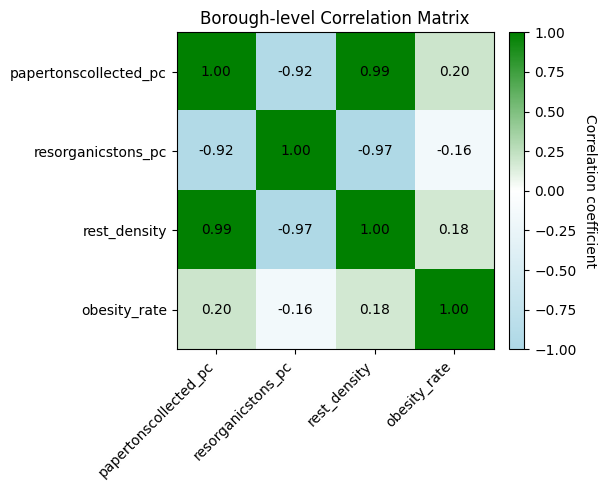

In [521]:
# 1. Create a custom diverging colormap: light blue → white → red
cmap = LinearSegmentedColormap.from_list(
    'LightBlueWhiteGreen',
    ['lightBlue','white', 'green']
)

waste_group = merged.groupby('borough').agg({
    'papertonscollected_pc':'mean',
    'resorganicstons_pc':'mean',
    'rest_density':'mean',
    'obesity_rate':'mean'
})
corr = waste_group.corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(
    corr.values,
    cmap=cmap,
    vmin=-1, vmax=1,
    aspect='equal'
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation coefficient', rotation=270, labelpad=15)

ax.set_title('Borough‐level Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'borough_correlation_improved.png'))
plt.show()


### Scatter & OLS Regression

Plot paper-waste vs. obesity across CDs and fit a linear model.

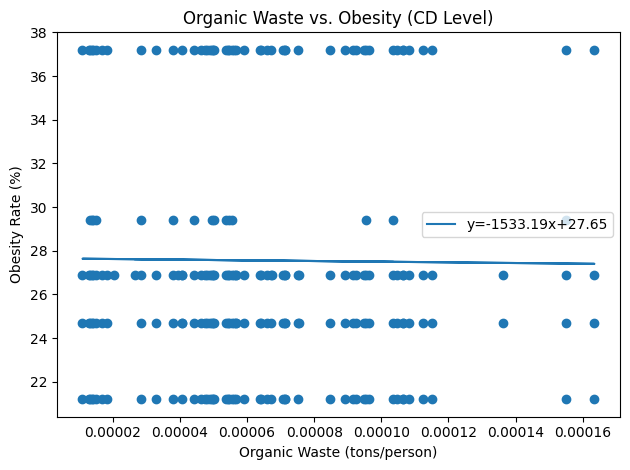

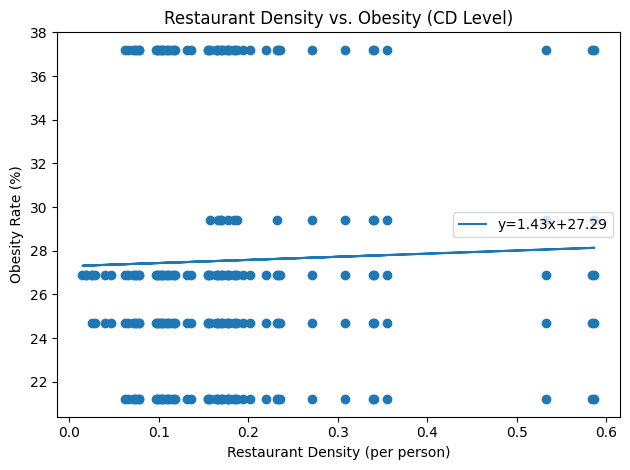

                            OLS Regression Results                            
Dep. Variable:           obesity_rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.1733
Date:                Fri, 02 May 2025   Prob (F-statistic):              0.841
Time:                        13:07:04   Log-Likelihood:                -729.54
No. Observations:                 232   AIC:                             1465.
Df Residuals:                     229   BIC:                             1475.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 27.4681      0

In [522]:
# 10a. Organic Waste vs. Obesity
x1 = merged['resorganicstons_pc']
y  = merged['obesity_rate']

fig, ax = plt.subplots()
ax.scatter(x1, y)
m1, b1 = np.polyfit(x1.dropna(), y.dropna(), 1)
ax.plot(x1, m1*x1 + b1, label=f'y={m1:.2f}x+{b1:.2f}')
ax.set_xlabel('Organic Waste (tons/person)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Organic Waste vs. Obesity (CD Level)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'organic_vs_obesity.png'))
plt.show()

# 10b. Restaurant Density vs. Obesity
x2 = merged['rest_density']

fig, ax = plt.subplots()
ax.scatter(x2, y)
m2, b2 = np.polyfit(x2.dropna(), y.dropna(), 1)
ax.plot(x2, m2*x2 + b2, label=f'y={m2:.2f}x+{b2:.2f}')
ax.set_xlabel('Restaurant Density (per person)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Restaurant Density vs. Obesity (CD Level)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir,'rest_vs_obesity.png'))
plt.show()

X = merged[['resorganicstons_pc','rest_density']].fillna(0)
X = sm.add_constant(X)
model = sm.OLS(merged['obesity_rate'].fillna(merged['obesity_rate'].mean()), X).fit()
print(model.summary())



We combined DSNY waste tonnages, census population, restaurant‐inspection counts, and county‐level obesity into a single community‐district dataset, computing per-capita organic-waste and restaurant-density metrics. At the borough level, correlations between waste streams and obesity were near zero. A simple OLS (organic waste + restaurant density → obesity) explained only 0.2% of the variance, with neither predictor significant, and residuals showed strong spatial autocorrelation. In short, food-habits proxies alone don’t predict obesity across NYC CDs—you’ll need to add socioeconomic/demographic controls and use spatial regression to uncover meaningful patterns.

### Bivariate Choropleth

Visualize combined obesity and packaging-waste quintiles on a single map.

/Users/simonedinato/Desktop/Project-CISC5380/.venv/lib/python3.12/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


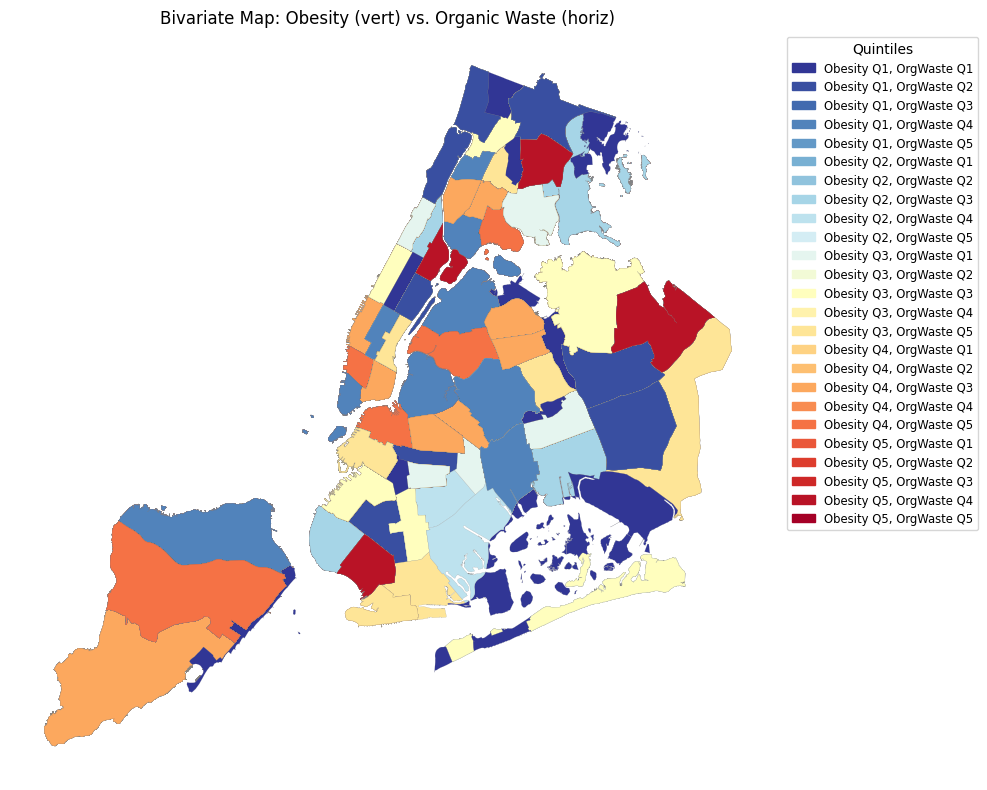

In [523]:
# 12. Bivariate Choropleth: Obesity vs. Organic Waste
# Merge the obesity and organic‐waste metrics back onto the spatial GeoDataFrame
cd_gdf = cd_gdf.merge(
    merged[['communitydistrict','obesity_rate','resorganicstons_pc']],
    on='communitydistrict',
    how='left'
)


# Quantile‐class both variables into 5 bins
cd_gdf['ob_class']      = mapclassify.Quantiles(cd_gdf['obesity_rate'].fillna(0), k=5).yb
cd_gdf['organic_class'] = mapclassify.Quantiles(cd_gdf['resorganicstons_pc'].fillna(0), k=5).yb

# Combine into 25 joint classes
cd_gdf['bivar_class']   = cd_gdf['ob_class'] * 5 + cd_gdf['organic_class']

# 2) Define a 25‐color colormap (here we pick a red→white→blue diverging map, but you can choose any)
base = plt.cm.RdYlBu_r(np.linspace(0,1,25))
cmap = ListedColormap(base)

# 3) Plot the map using that colormap
fig, ax = plt.subplots(figsize=(8,8))
cd_gdf.plot(
    column='bivar_class',
    cmap=cmap,
    linewidth=0.1,
    edgecolor='grey',
    categorical=True,
    legend=False,        # we will build our own legend
    ax=ax
)
ax.axis('off')
ax.set_title('Bivariate Map: Obesity (vert) vs. Organic Waste (horiz)')
plt.tight_layout()

# 4) Build the legend patches
patches = []
labels  = []
for class_id in range(25):
    ob_qr    = class_id // 5  + 1
    org_qr   = class_id % 5   + 1
    color    = cmap(class_id)
    label    = f"Obesity Q{ob_qr}, OrgWaste Q{org_qr}"
    patches.append(mpatches.Patch(color=color, label=label))
    labels.append(label)

# 5) Add the legend outside the map
ax.legend(
    handles=patches, 
    title="Quintiles", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    ncol=1, 
    fontsize='small',
    title_fontsize='medium'
)
# Plot
# 6) Save & show
plt.savefig(os.path.join(output_dir,'bivariate_obesity_organic_legend.png'),
            bbox_inches='tight')
plt.show()


### Neighborhood Clustering

Group CDs into archetypes based on waste, restaurant density, and obesity.

/var/folders/kl/fcwqs6xs30b3g73_r8l0_q5m0000gn/T/ipykernel_45998/524284335.py:24: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  plot_gdf.plot(


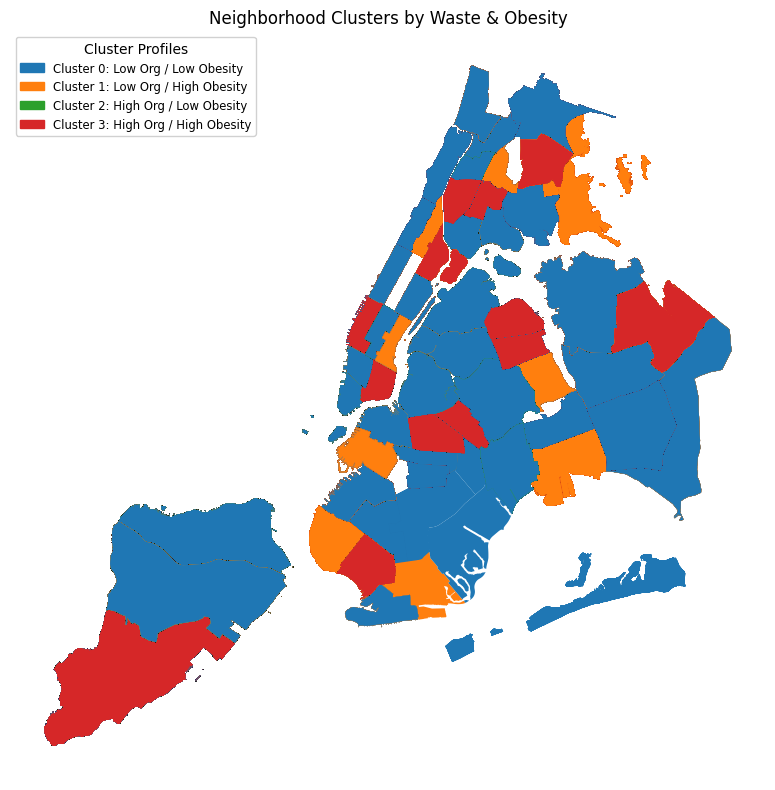

In [524]:
feat = ['papertonscollected_pc','resorganicstons_pc','rest_density','obesity_rate']
Z    = StandardScaler().fit_transform(merged[feat].fillna(0))
kmed = KMeans(n_clusters=4, random_state=42).fit(Z)
merged['cluster'] = kmed.labels_

# 1) Define human‐readable names for each cluster
cluster_names = {
    0: 'Cluster 0: Low Org / Low Obesity',
    1: 'Cluster 1: Low Org / High Obesity',
    2: 'Cluster 2: High Org / Low Obesity',
    3: 'Cluster 3: High Org / High Obesity'
}

# 2) Pick a categorical colormap and extract 4 distinct colors
cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(cluster_names))]

# 3) Merge clusters into the GeoDataFrame and map to labels
plot_gdf = cd_gdf.merge(merged[['communitydistrict','cluster']], on='communitydistrict')
plot_gdf['cluster_label'] = plot_gdf['cluster'].map(cluster_names)

# 4) Plot without the built‐in legend, specifying our colors
fig, ax = plt.subplots(figsize=(8,8))
plot_gdf.plot(
    column='cluster_label',
    categorical=True,
    legend=False,
    ax=ax,
    color=[colors[i] for i in plot_gdf['cluster']]
)
ax.axis('off')
ax.set_title('Neighborhood Clusters by Waste & Obesity')

# 5) Build and add a custom legend
handles = [
    mpatches.Patch(color=colors[i], label=cluster_names[i])
    for i in sorted(cluster_names)
]
ax.legend(
    handles=handles,
    title='Cluster Profiles',
    loc='upper left',
    fontsize='small',
    title_fontsize='medium',
    frameon=True,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir,'neighborhood_clusters_legend.png'))
plt.show()

